Below is a scaffold for `exploration.ipynb` aimed at students with limited Python. It gives structure, comments, and guidance, but omits the heavy “main calls” so you must wire things together yourself. Complex classes are kept; simple glue code is left as TODO or pseudo‑code.

In [ ]:
# 01_exploration.ipynb
# Goal of this notebook:
# - Check that the ISLES 2022 dataset is correctly downloaded and unpacked
# - Explore basic image properties (sizes, voxel spacing)
# - Preprocess images (resampling, normalization, masks)
# - Extract radiomic features into a single CSV table
#
# You do NOT have to understand every line, but you should understand:
# - What each section is trying to achieve
# - Which functions / classes you need to call
# - Where the main inputs and outputs are on disk

***

## 0. Setup paths and basic imports

In [3]:
import os
from pathlib import Path

# 0.1 Set je project root
PROJECTROOT = Path.home() / "AIIP-radiomics-project"
os.chdir(PROJECTROOT)

# 0.2 Omdat jouw ISLES-map direct in de projectmap staat, maken we RAWROOT gelijk aan PROJECTROOT
RAWROOT = PROJECTROOT 
PROCROOT = PROJECTROOT / "data" / "processed"
RESULTS = PROJECTROOT / "results"

# 0.3 Mappen aanmaken (deze zoekt nu correct naar AIIP-radiomics-project/ISLES-2022)
(RAWROOT / "ISLES-2022").mkdir(parents=True, exist_ok=True)
(PROCROOT / "ISLES-2022").mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

print("Working directory:", os.getcwd())
print("Raw root:", RAWROOT)
print("Processed root:", PROCROOT)

Working directory: /home/jovyan/AIIP-radiomics-project
Raw root: /home/jovyan/AIIP-radiomics-project
Processed root: /home/jovyan/AIIP-radiomics-project/data/processed


**Student direction:**

- Check that `data/raw/ISLES-2022` contains the unzipped ISLES dataset (BIDS‑like structure).
- If not, go back to the quick‑start instructions and download/unzip ISLES first.

***

## 1. Explore the ISLES dataset structure

Here we define a loader that knows the ISLES folder layout. You do **not** need to modify this class; you only need to call its methods later.

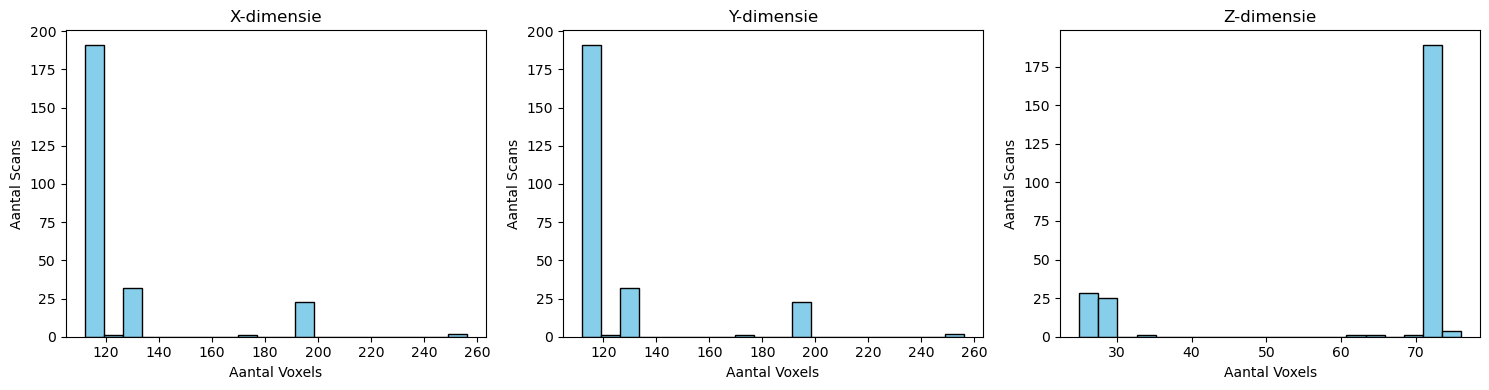

Aantal succesvol geladen cases: 250


In [7]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

class ISLESDataLoader:
    def __init__(self, rawroot: str | Path):
        rawroot = Path(rawroot)
        if not rawroot.exists():
            raise FileNotFoundError(f"data/raw directory not found: {rawroot}")

        islesroot = rawroot / "ISLES-2022"
        if not islesroot.exists():
            islesroot = rawroot

        self.islesroot = islesroot
        self.derivativesroot = islesroot / "derivatives"

        self.casedirs = sorted(
            d for d in self.islesroot.iterdir()
            if d.is_dir() and d.name.startswith("sub-strokecase")
        )

    def get_session_dir(self, subdir: Path) -> Path:
        sesdir = subdir / "ses-0001"
        if not sesdir.exists():
            raise FileNotFoundError(f"Missing ses-0001 for {subdir.name}")
        return sesdir

    def get_dwi_path(self, sesdir: Path) -> Path | None:
        dwidir = sesdir / "dwi"
        if not dwidir.exists():
            return None
        candidates = sorted(dwidir.glob("*dwi.nii.gz"))
        if not candidates:
            candidates = sorted(p for p in dwidir.glob("*.nii.gz") if "adc" not in p.name.lower())
        return candidates[0] if candidates else None

    def get_mask_path(self, subid: str) -> Path | None:
        if not self.derivativesroot.exists():
            return None
        sesdir = self.derivativesroot / subid / "ses-0001"
        if not sesdir.exists():
            return None
        candidates = sorted(sesdir.glob("*msk.nii.gz"))
        return candidates[0] if candidates else None

    def explore_dataset(self):
        sizes = []
        spacings = []

        for subdir in self.casedirs:
            subid = subdir.name
            try:
                sesdir = self.get_session_dir(subdir)
            except FileNotFoundError:
                continue

            dwipath = self.get_dwi_path(sesdir)
            if dwipath is None:
                continue

            try:
                img = nib.load(str(dwipath))
            except Exception:
                continue

            shape = img.shape
            if len(shape) != 3:
                continue

            sizes.append(shape)
            spacings.append(img.header.get_zooms())

        if not sizes:
            print("No valid cases collected. Check ISLES-2022 structure under data/raw.")
            return [], []

        sizes_array = np.array(sizes)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        titles = ['X-dimensie', 'Y-dimensie', 'Z-dimensie']
        
        for dim in range(3):
            axes[dim].hist(sizes_array[:, dim], bins=20, color='skyblue', edgecolor='black')
            axes[dim].set_title(titles[dim])
            axes[dim].set_xlabel('Aantal Voxels')
            axes[dim].set_ylabel('Aantal Scans')
            
        plt.tight_layout()
        plt.show()

        return sizes, spacings

# UITVOEREN VAN DE CODE:
loader = ISLESDataLoader(RAWROOT)
sizes, spacings = loader.explore_dataset()
print(f"Aantal succesvol geladen cases: {len(sizes)}")

**Student direction:**

- Instantiate `ISLESDataLoader` with `RAWROOT` and call `explore_dataset()`.
- Look at the printed warnings and the basic statistics (number of cases, typical sizes).
- Optionally add a quick plot of one DWI slice and its mask to get a feeling for the data.

***

## 2. Preprocessing images into a uniform space

This class encapsulates the “heavy lifting” for preprocessing. You mostly need to understand **input** and **output**:

- Input: raw ISLES folders in `data/raw/ISLES-2022/…`
- Output: preprocessed NIfTI files in `data/processed/ISLES-2022/preproc/sub-…/ses-0001/…`

In [8]:
from nibabel.processing import resample_to_output
from tqdm.auto import tqdm

class ImagePreprocessing:
    def __init__(self, rawroot: str | Path, outroot: str | Path, target_spacing=(1.0, 1.0, 1.0)):
        self.rawroot = Path(rawroot)
        self.outroot = Path(outroot) / "ISLES-2022" / "preproc"
        self.target_spacing = target_spacing

        islesroot = self.rawroot / "ISLES-2022"
        if not islesroot.exists():
            islesroot = self.rawroot
        self.islesroot = islesroot
        self.derivativesroot = islesroot / "derivatives"

        self.casedirs = sorted(
            d for d in self.islesroot.iterdir()
            if d.is_dir() and d.name.startswith("sub-strokecase")
        )

    def get_session_dir(self, subdir: Path) -> Path:
        sesdir = subdir / "ses-0001"
        if not sesdir.exists():
            raise FileNotFoundError(f"Missing ses-0001 for {subdir.name}")
        return sesdir

    def find_modality_paths(self, sesdir: Path):
        paths = {"FLAIR": None, "DWI": None, "ADC": None}
        anatdir = sesdir / "anat"
        if anatdir.exists():
            flaircand = sorted(anatdir.glob("*FLAIR.nii.gz"))
            if flaircand: paths["FLAIR"] = flaircand[0]

        dwidir = sesdir / "dwi"
        if dwidir.exists():
            dwicand = sorted(dwidir.glob("*dwi.nii.gz"))
            adccand = sorted(dwidir.glob("*adc.nii.gz"))
            if dwicand: paths["DWI"] = dwicand[0]
            if adccand: paths["ADC"] = adccand[0]
        return paths

    def find_mask_path(self, subid: str) -> Path | None:
        if not self.derivativesroot.exists(): return None
        subderiv = self.derivativesroot / subid / "ses-0001"
        if not subderiv.exists(): return None
        mskcand = sorted(subderiv.glob("*msk.nii.gz"))
        return mskcand[0] if mskcand else None

    def resample_iso(self, img: nib.Nifti1Image) -> nib.Nifti1Image:
        return resample_to_output(img, voxel_sizes=self.target_spacing)

    def zscore_normalize(self, img: nib.Nifti1Image, mask: nib.Nifti1Image | None = None):
        data = img.get_fdata().astype(np.float32)
        m = mask.get_fdata() > 0 if mask is not None else data != 0

        if m.sum() == 0: return img

        vals = data[m]
        mean = float(vals.mean())
        std = float(vals.std()) if vals.std() != 0 else 1.0

        data[m] = (vals - mean) / std
        return nib.Nifti1Image(data, img.affine, img.header)

    def run(self):
        self.outroot.mkdir(parents=True, exist_ok=True)

        for subdir in tqdm(self.casedirs, desc="Preprocessing", unit="case"):
            subid = subdir.name
            
            out_sub = self.outroot / subid / "ses-0001"
            if out_sub.exists() and any(out_sub.iterdir()):
                continue  # Sla deze iteratie over en ga direct naar de volgende patiënt
            
            try:
                sesdir = self.get_session_dir(subdir)
            except FileNotFoundError:
                continue

            modpaths = self.find_modality_paths(sesdir)
            maskpath = self.find_mask_path(subid)

            # UITGEWERKTE PSEUDOCODE:
            # Check of we überhaupt data hebben
            if all(p is None for p in modpaths.values()):
                continue
            
            out_sub = self.outroot / subid / "ses-0001"
            out_sub.mkdir(parents=True, exist_ok=True)

            # Modalities verwerken
            for mod_name, path in modpaths.items():
                if path is not None:
                    img = nib.load(str(path))
                    resampled_img = self.resample_iso(img)
                    
                    if mod_name in ["FLAIR", "DWI"]:
                        final_img = self.zscore_normalize(resampled_img)
                    else:
                        final_img = resampled_img # ADC doen we niet normaliseren
                        
                    nib.save(final_img, str(out_sub / f"{mod_name}preproc.nii.gz"))

            # Masker verwerken
            if maskpath is not None:
                msk = nib.load(str(maskpath))
                resampled_msk = self.resample_iso(msk)
                
                # Binarize (threshold > 0.5)
                msk_data = resampled_msk.get_fdata()
                bin_data = (msk_data > 0.5).astype(np.uint8)
                final_msk = nib.Nifti1Image(bin_data, resampled_msk.affine, resampled_msk.header)
                
                nib.save(final_msk, str(out_sub / "MSKpreproc.nii.gz"))

        print("Preprocessing complete. Check:", self.outroot)

# UITVOEREN VAN DE CODE:
preprocessor = ImagePreprocessing(RAWROOT, PROCROOT)
preprocessor.run()

Preprocessing: 100%|██████████| 250/250 [00:00<00:00, 2299.77case/s]

Preprocessing complete. Check: /home/jovyan/AIIP-radiomics-project/data/processed/ISLES-2022/preproc


**Student direction:**

- After reading through comments, instantiate `ImagePreprocessing` and call `run()`.
- Then, explore one or two `*_preproc.nii.gz` files (e.g., load and plot a slice) to see the result.

***

## 3. Radiomics feature extraction

Radiomics can feel “black box”. The important part is:

- Inputs: `DWIpreproc.nii.gz` + `MSKpreproc.nii.gz` for each subject.
- Output: one row per subject, with many numeric feature columns.

Below is a simplified wrapper; the body of `extract_case` does the detailed work.

In [14]:
from radiomics import featureextractor
import pandas as pd

class RadiomicsExtractor:
    def __init__(self, params_file: str = "code/radiomics_params.yaml"):
        self.extractor = featureextractor.RadiomicsFeatureExtractor(params_file)

    def extract_case(self, casedir: Path) -> dict | None:
        imgpath = casedir / "ses-0001" / "DWIpreproc.nii.gz"
        mskpath = casedir / "ses-0001" / "MSKpreproc.nii.gz"

        if not imgpath.exists() or not mskpath.exists():
            return None

        try:
            result = self.extractor.execute(str(imgpath), str(mskpath))
        except ValueError as e:
            # Als het masker leeg is, print een waarschuwing en sla deze patiënt over
            print(f"Skipping {casedir.name}: {e}")
            return None
        except Exception as e:
            # Vang eventuele andere onverwachte fouten netjes af
            print(f"Error processing {casedir.name}: {e}")
            return None


        out = {"caseid": casedir.name}
        for k, v in result.items():
            if k.startswith("original"):
                try:
                    out[k] = float(v)
                except Exception:
                    continue
        return out

    def extract_all_cases(self, processed_root: str | Path) -> pd.DataFrame:
        processed_root = Path(processed_root)
        casedirs = sorted(
            d for d in processed_root.iterdir()
            if d.is_dir() and d.name.startswith("sub-strokecase")
        )

        rows = []
        for d in tqdm(casedirs, desc="Radiomics", unit="case"):
            row = self.extract_case(d)
            if row is not None:
                rows.append(row)

        if not rows:
            print("No features extracted. Check preprocessed images and masks.")
            return pd.DataFrame()

        return pd.DataFrame(rows).set_index("caseid")

# UITVOEREN VAN DE CODE:
try:
    extractor = RadiomicsExtractor("radiomics_params.yaml")
    features_df = extractor.extract_all_cases(PROCROOT / "ISLES-2022" / "preproc")
    
    if not features_df.empty:
        features_df.to_csv(PROCROOT / "features_raw.csv")
        print(f"Extracted shape: {features_df.shape}")
        print(features_df.head())
except Exception as e:
    print(f"Let op: Radiomics extractie mislukt. Heb je de YAML file aangemaakt? Foutmelding: {e}")

Radiomics:  60%|██████    | 150/250 [05:30<02:21,  1.41s/case]

Skipping sub-strokecase0150: No labels found in this mask (i.e. nothing is segmented)!


Radiomics:  60%|██████    | 151/250 [05:30<01:50,  1.12s/case]

Skipping sub-strokecase0151: No labels found in this mask (i.e. nothing is segmented)!


Radiomics:  68%|██████▊   | 170/250 [06:04<02:01,  1.52s/case]

Skipping sub-strokecase0170: No labels found in this mask (i.e. nothing is segmented)!


Radiomics: 100%|██████████| 250/250 [08:41<00:00,  2.09s/case]

Extracted shape: (246, 105)
                    original_shape_Elongation  original_shape_Flatness  \
caseid                                                                   
sub-strokecase0001                   0.363839                 0.323387   
sub-strokecase0002                   0.902266                 0.550178   
sub-strokecase0003                   0.587263                 0.440001   
sub-strokecase0004                   0.767924                 0.259318   
sub-strokecase0005                   0.396086                 0.217450   

                    original_shape_LeastAxisLength  \
caseid                                               
sub-strokecase0001                       56.828030   
sub-strokecase0002                        8.489684   
sub-strokecase0003                       33.240104   
sub-strokecase0004                       18.063787   
sub-strokecase0005                       23.442018   

                    original_shape_MajorAxisLength  \
caseid              

**Student direction:**

- Decide on the **params file** (we provide one at `code/radiomics_params.yaml`).
- Call `extract_all_cases` on the preprocessed root (e.g. `data/processed/ISLES-2022/preproc`).
- Save the resulting DataFrame:

In [10]:
# PSEUDOCODE:
# extractor = RadiomicsExtractor("code/radiomics_params.yaml")
# features_df = extractor.extract_all_cases(PROCROOT / "ISLES-2022" / "preproc")
# features_df.to_csv(PROCROOT / "features_raw.csv")
# print(features_df.shape)
# print(features_df.head())

***

## 4. Optional: First look at center‑wise stability

You will revisit stability in more detail later, but here is a minimal sketch of how the provided `StabilityAnalysis` class is used. You do not need to modify it; just understand that:

- It attaches a `center` label to each case (from a CSV).
- For each feature, it compares between‑center and within‑center variance.

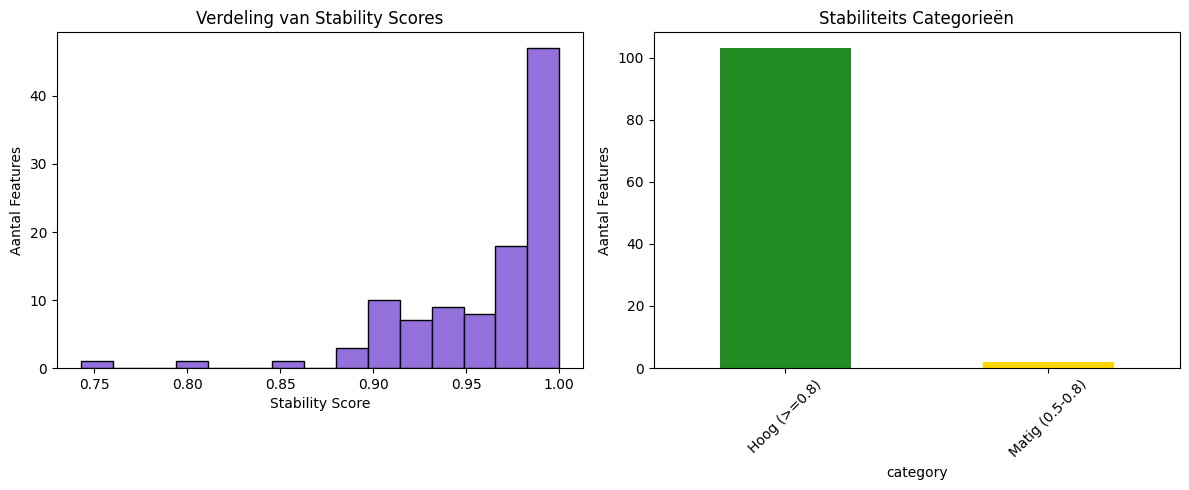

Succes! De stabiliteitsplot is gegenereerd.


In [17]:
import pandas as pd
import os
from pathlib import Path

PROJECTROOT = Path.home() / "AIIP-radiomics-project"
PROCROOT = PROJECTROOT / "data" / "processed"
RESULTS = PROJECTROOT / "results"

# 1. Lees de eerder opgeslagen features in
features_df = pd.read_csv(PROCROOT / "features_raw.csv", index_col="caseid")

# 2. Definieer de JUISTE locatie van de excel-file
# Hij zoekt nu in AIIP-radiomics-project/center_ids.xlsx
excel_path = PROJECTROOT / "center_ids.xlsx"

if not excel_path.exists():
    print(f"Let op: Kan het excel-bestand niet vinden op: {excel_path}")
else:
    try:
        # We geven de variabele door aan de class
        analyzer = StabilityAnalysis(features_df, centercsv=excel_path)
        stability_results = analyzer.compute_stability_all_features()
        analyzer.visualize_stability(output_path=RESULTS)
        print("Succes! De stabiliteitsplot is gegenereerd.")
    except Exception as e:
        print(f"Stabiliteitsanalyse gecrasht: {e}")


In [16]:
class StabilityAnalysis:
    def __init__(self, features_df: pd.DataFrame, centercsv: str = "data/raw/centerids.csv",
                 min_cases_per_center: int = 10, min_centers_with_data: int = 2):
        self.features_df = features_df.copy()
        if self.features_df.index.name is None:
            self.features_df.index.name = "caseid"
            
        # Check of het bestand bestaat
        if not Path(centercsv).exists():
            raise FileNotFoundError(f"Missing center_ids file at {centercsv}")

        file_path = str(centercsv)
        if file_path.endswith('.xlsx') or file_path.endswith('.xls'):
            centers_df = pd.read_excel(file_path)
        else:
            centers_df = pd.read_csv(file_path)

        # Schoon de kolomnamen op (alles kleine letters, haal spaties voor/achter weg)
        centers_df.columns = [str(c).lower().strip() for c in centers_df.columns]
        
        # Hernoem de gevonden kolommen 'case' en 'center' (of varianten daarop) naar wat de code verwacht
        if 'case' in centers_df.columns:
            centers_df = centers_df.rename(columns={'case': 'caseid'})
        elif 'case id' in centers_df.columns:
            centers_df = centers_df.rename(columns={'case id': 'caseid'})
        elif 'case_id' in centers_df.columns:
            centers_df = centers_df.rename(columns={'case_id': 'caseid'})
            
        if 'center' in centers_df.columns:
            centers_df = centers_df.rename(columns={'center': 'centerid'})
        elif 'center id' in centers_df.columns:
            centers_df = centers_df.rename(columns={'center id': 'centerid'})
        elif 'center_id' in centers_df.columns:
            centers_df = centers_df.rename(columns={'center_id': 'centerid'})

        # Extra veiligheidscheck
        if "caseid" not in centers_df.columns or "centerid" not in centers_df.columns:
            raise KeyError(f"Ik mis de kolommen 'caseid' of 'centerid'. Huidige kolommen zijn: {centers_df.columns.tolist()}")

        centers_df["caseid"] = centers_df["caseid"].astype(str)
        centers_df["centerid"] = centers_df["centerid"].astype(str)

        idx_caseids = self.features_df.index.astype(str)
        centers_df = centers_df[centers_df["caseid"].isin(idx_caseids)].set_index("caseid")
        self.features_df["center"] = idx_caseids.map(centers_df["centerid"])
        self.features_df = self.features_df.dropna(subset=["center"])

        self.min_cases_per_center = min_cases_per_center
        self.min_centers_with_data = min_centers_with_data
        self.results = None

    def compute_stability_all_features(self) -> pd.DataFrame:
        results = []
        feature_cols = [c for c in self.features_df.columns if c != "center"]
        
        for feat in feature_cols:
            df_feat = self.features_df[[feat, 'center']].dropna()
            
            center_counts = df_feat['center'].value_counts()
            valid_centers = center_counts[center_counts >= self.min_cases_per_center].index
            df_feat = df_feat[df_feat['center'].isin(valid_centers)]
            
            if df_feat['center'].nunique() < self.min_centers_with_data:
                continue
                
            group_means = df_feat.groupby('center')[feat].mean()
            group_vars = df_feat.groupby('center')[feat].var()
            
            var_between = group_means.var() if len(group_means) > 1 else 0
            var_within = group_vars.mean()
            
            instability_ratio = var_between / (var_within + 1e-8)
            stability_score = max(0.0, 1.0 - instability_ratio)
            
            results.append({
                "feature": feat,
                "var_between": var_between,
                "var_within": var_within,
                "instability_ratio": instability_ratio,
                "stability_score": stability_score
            })
            
        self.results = pd.DataFrame(results).set_index("feature")
        return self.results

    def visualize_stability(self, output_path: str = "results"):
        import matplotlib.pyplot as plt
        import numpy as np
        
        if self.results is None or self.results.empty:
            print("Geen stabiliteitsresultaten om te visualiseren.")
            return
            
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))
        
        ax[0].hist(self.results["stability_score"], bins=15, color="mediumpurple", edgecolor="black")
        ax[0].set_title("Verdeling van Stability Scores")
        ax[0].set_xlabel("Stability Score")
        ax[0].set_ylabel("Aantal Features")
        
        conditions = [
            (self.results["stability_score"] >= 0.8),
            (self.results["stability_score"] >= 0.5) & (self.results["stability_score"] < 0.8),
            (self.results["stability_score"] < 0.5)
        ]
        choices = ["Hoog (>=0.8)", "Matig (0.5-0.8)", "Laag (<0.5)"]
        self.results["category"] = np.select(conditions, choices, default="Onbekend")
        
        counts = self.results["category"].value_counts()
        counts.plot(kind="bar", ax=ax[1], color=["forestgreen", "gold", "crimson"])
        ax[1].set_title("Stabiliteits Categorieën")
        ax[1].set_ylabel("Aantal Features")
        ax[1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        out_dir = Path(output_path)
        out_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_dir / "stability_analysis.png")
        plt.show()


**Student direction:**

Later, you will:

In [17]:
# PSEUDOCODE:
# analyzer = StabilityAnalysis(features_df, centercsv=RAWROOT / "centerids.csv")
# stability_results = analyzer.compute_stability_all_features()
# analyzer.visualize_stability(output_path=RESULTS)

For now, it is enough to know that this class will help you decide which features are more stable across centers.

***

## 5. Checklist for this first notebook

By the time you finish `01_exploration.ipynb`, you should have:

- Verified that ISLES is correctly downloaded and readable (no or few fatal warnings from the loader).
- Preprocessed images saved under `data/processed/ISLES-2022/preproc/sub-…/ses-0001/`.
- A radiomics feature table saved as something like `data/processed/features_raw.csv`.
- A basic understanding of:
    - What each preprocessing step does (resampling, normalization, masking).
    - What radiomic features represent (one row per case, many quantitative descriptors).

You do **not** need perfect plots or fully polished code yet; the main goal is to get a clean, reproducible input for the later notebooks.